# Automatic Classification of Martian Surface Features Using Convolutional Neural Networks

## Project Overview
The focus of this project is the creation of a deep learning model for an image classification problem. The aim of this project is the creation of a neural network that can classify images using the information learned from the images.

Deep learning models, especially CNNs, are considered the best for image-related problems. This is because they can learn from the images. CNNs have the ability to learn from the images. In this project, the CNN model is used to learn from the images.

## Dataset Description
The dataset consists of labeled images belonging to multiple classes. Each image file is associated with a class label that represents the category it belongs to. The dataset is organised using a dataframe that stores:

- **filename** – the image file name
- **class** – the category label of the image
- **filepath** – the full path to the image file
- **label** – the numerical encoding of each class label used for model training

In order to prepare the data set to be trained, file paths are generated programmatically, and the class labels are converted into numerical indices to be utilized by the neural network.

## Data Preprocessing
Before training the model, several preprocessing steps are applied:

- Constructing full file paths for all images
- Converting categorical class labels into numerical labels
- Exploring the dataset to understand the distribution of classes
- Visualizing sample images and dataset statistics
- Preparing the data for model training

These preprocessing steps ensure the data is structured correctly and suitable for deep learning training.

## Project Workflow
The overall workflow of this project consists of the following stages:

1. **Dataset Preparation**
   - Load dataset metadata
   - Generate image file paths
   - Encode class labels

2. **Exploratory Data Analysis**
   - Visualize dataset samples
   - Plot class distribution
   - Understand dataset balance

3. **Model Development**
   - Design the neural network architecture
   - Configure training parameters
   - Compile the model

4. **Model Training**
   - Train the network on the training dataset
   - Monitor training and validation performance
   - Adjust parameters if necessary

5. **Model Evaluation**
   - Evaluate final model performance
   - Analyze predictions and classification results
   - Visualize performance metrics

## Objective
The primary aim of this project is to create a deep learning model that can classify images correctly while showing the entire machine learning cycle, including data preprocessing, training, monitoring, and evaluation.

The results obtained from the model will be used to determine the success of the model, as well as possible improvements for future work.


In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from PIL import Image

In [28]:
import pandas as pd

# Mapping from class ID to class name
class_map = {
    "0": "other",
    "1": "crater",
    "2": "dark dune",
    "3": "slope streak",
    "4": "bright dune",
    "5": "impact ejecta",
    "6": "swiss cheese",
    "7": "spider"
}

data = []
with open("labels-map-proj-v3.txt", "r") as f:
    for line in f:
        parts = line.strip().split()  # split by spaces
        # Each line can have multiple filename-class pairs
        for i in range(0, len(parts), 2):
            filename = parts[i]
            class_id = parts[i+1]
            class_name = class_map[class_id]
            data.append([filename, class_name])

# Create CSV
df = pd.DataFrame(data, columns=["filename", "class"])
df.to_csv("landmarks_map-proj-v3_classmap.csv", index=False)
print("CSV created successfully!")

CSV created successfully!


In [29]:
csv_file = "landmarks_map-proj-v3_classmap.csv"     # your generated csv
img_dir = "map-proj-v3"     # image folder

df = pd.read_csv(csv_file)

print(df.head())
print(df.tail())
print("Total images:", len(df))

                            filename  class
0       ESP_011623_2100_RED-0069.jpg  other
1   ESP_011623_2100_RED-0069-r90.jpg  other
2  ESP_011623_2100_RED-0069-r180.jpg  other
3  ESP_011623_2100_RED-0069-r270.jpg  other
4    ESP_011623_2100_RED-0069-fh.jpg  other
                                filename  class
73026  PSP_010461_1845_RED-0032-r180.jpg  other
73027  PSP_010461_1845_RED-0032-r270.jpg  other
73028    PSP_010461_1845_RED-0032-fh.jpg  other
73029    PSP_010461_1845_RED-0032-fv.jpg  other
73030   PSP_010461_1845_RED-0032-brt.jpg  other
Total images: 73031


In [30]:
# Convert class names → numbers
class_names = sorted(df["class"].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

df["label"] = df["class"].map(class_to_idx)

print(class_to_idx)

{'bright dune': 0, 'crater': 1, 'dark dune': 2, 'impact ejecta': 3, 'other': 4, 'slope streak': 5, 'spider': 6, 'swiss cheese': 7}


In [31]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 58424
Test: 14607


In [32]:
IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0   # normalize
    return image, label

In [33]:
import os

IMG_DIR = "map-proj-v3"

# Create full image path column
df["filepath"] = df["filename"].apply(
    lambda x: os.path.join(IMG_DIR, x)
)

# Convert class names → numeric labels
class_names = sorted(df["class"].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

df["label"] = df["class"].map(class_to_idx)

print(df.head())

                            filename  class  label  \
0       ESP_011623_2100_RED-0069.jpg  other      4   
1   ESP_011623_2100_RED-0069-r90.jpg  other      4   
2  ESP_011623_2100_RED-0069-r180.jpg  other      4   
3  ESP_011623_2100_RED-0069-r270.jpg  other      4   
4    ESP_011623_2100_RED-0069-fh.jpg  other      4   

                                        filepath  
0       map-proj-v3/ESP_011623_2100_RED-0069.jpg  
1   map-proj-v3/ESP_011623_2100_RED-0069-r90.jpg  
2  map-proj-v3/ESP_011623_2100_RED-0069-r180.jpg  
3  map-proj-v3/ESP_011623_2100_RED-0069-r270.jpg  
4    map-proj-v3/ESP_011623_2100_RED-0069-fh.jpg  


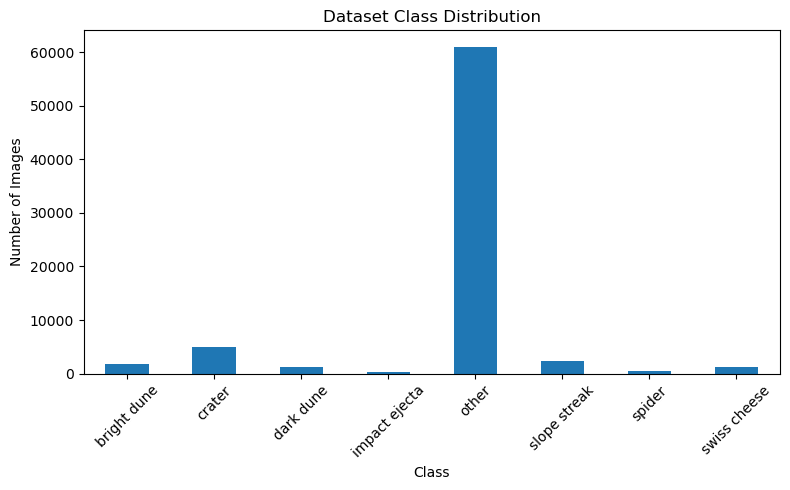

In [34]:


# Count number of samples per class
class_counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")

plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [36]:
# 1️Stratified split
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# Optional: check class distributions
print("Train distribution:\n", train_df["label"].value_counts())
print("Test distribution:\n", test_df["label"].value_counts())

# TensorFlow dataset creation
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["label"].values)
)
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_df["label"].values)
)

#  Preprocessing function
def preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (128,128))
    image = image / 255.0
    return image, label

train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

#  Data augmentation (training only)
from tensorflow.keras import layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                        num_parallel_calls=tf.data.AUTOTUNE)

#  Shuffle, batch, prefetch
BATCH_SIZE = 32
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Dataset ready")

Train distribution:
 label
4    48842
1     3920
5     1865
0     1400
7      918
2      913
6      381
3      185
Name: count, dtype: int64
Test distribution:
 label
4    12212
1      980
5      466
0      350
7      230
2      228
6       95
3       46
Name: count, dtype: int64
Dataset ready


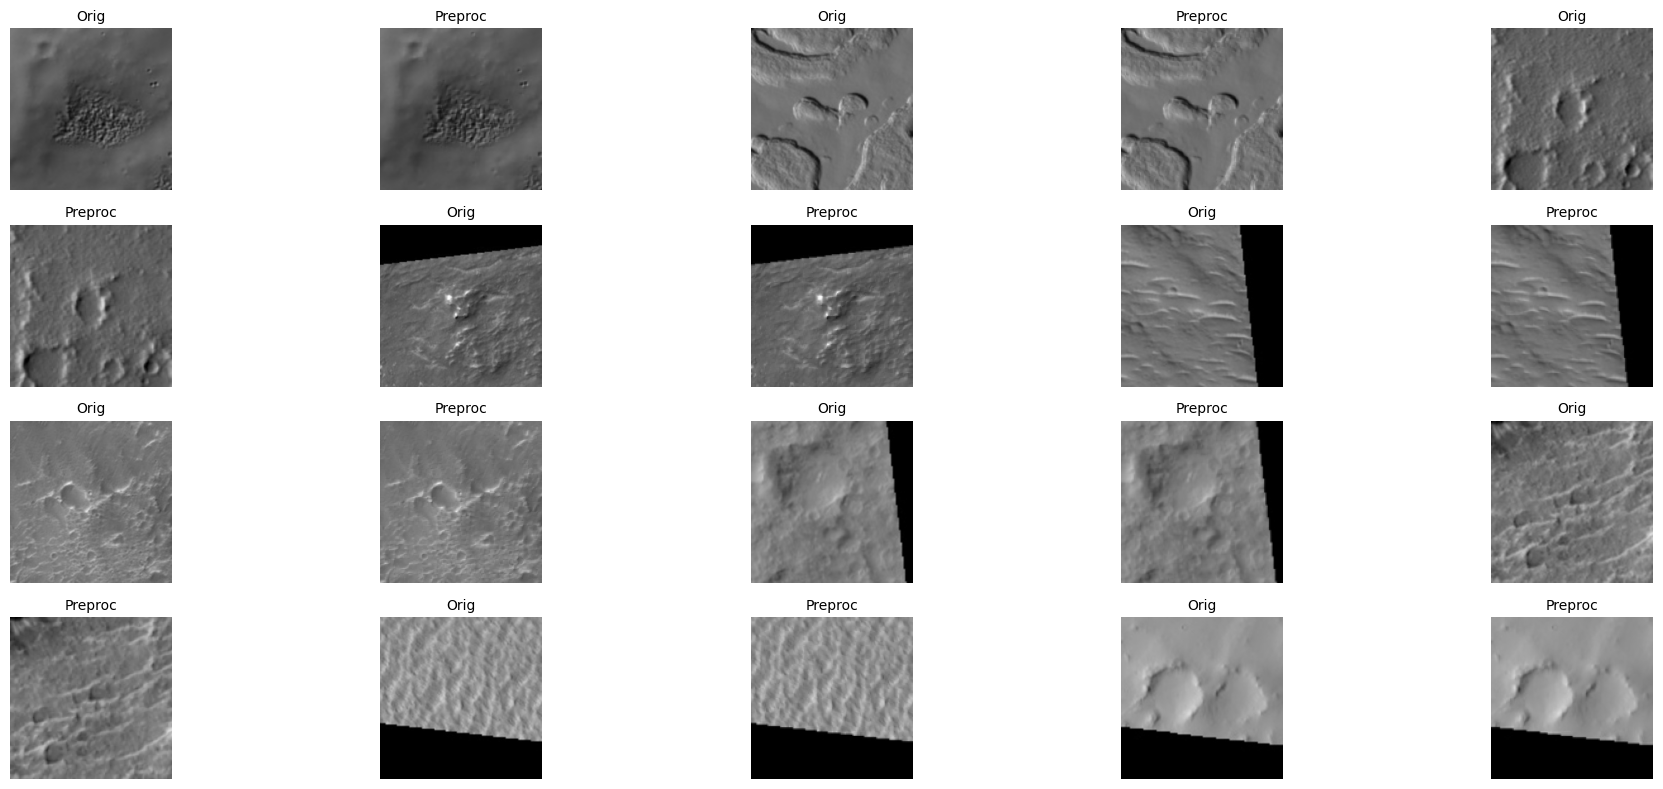

In [23]:
import matplotlib.pyplot as plt
from PIL import Image

# Set a random seed for reproducibility
seed = 42

# Sample 10 images reproducibly
sample = df.sample(10, random_state=seed)

num_images = len(sample) * 2  # original + preprocessed
cols = 5  # images per row
rows = (num_images + cols - 1) // cols  # calculate rows

fig, axes = plt.subplots(rows, cols, figsize=(20, 8))
axes = axes.flatten()  # flatten in case rows>1

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["filepath"]).convert("RGB")
    processed = preprocess_image(row["filepath"], 0)[0].numpy()

    # Original image
    axes[i*2].imshow(img)
    axes[i*2].set_title("Orig", fontsize=10)
    axes[i*2].axis("off")

    # Preprocessed image
    axes[i*2+1].imshow(processed)
    axes[i*2+1].set_title("Preproc", fontsize=10)
    axes[i*2+1].axis("off")

# Hide any remaining axes
for ax in axes[num_images:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Convolutional Neural Network (CNN) Architecture

The architecture of the proposed Convolutional Neural Network used for Martian surface feature classification is illustrated below.

![CNN Architecture](cnn_architecture.png)

### Model Architecture Explanation

The model is designed as a deep convolutional neural network consisting of three convolutional blocks followed by fully connected layers for classification.

#### 1. Input Layer
The network takes an input image of size **128 × 128 × 3**, representing RGB images of Martian surface features.

#### 2. Convolutional Block 1
The first convolutional block extracts low-level visual features such as edges and textures.
- **Conv2D layer:** 32 filters with a 3×3 kernel
- **ReLU activation:** introduces non-linearity
- **MaxPooling (2×2):** reduces spatial dimensions and computation

The resulting feature map size becomes **64 × 64 × 32**.

#### 3. Convolutional Block 2
This layer captures more complex patterns and structures in the image.
- **Conv2D layer:** 64 filters with a 3×3 kernel
- **ReLU activation**
- **MaxPooling (2×2)**

Output feature map size: **32 × 32 × 64**.

#### 4. Convolutional Block 3
The third convolutional block learns higher-level abstract features relevant to surface formations.
- **Conv2D layer:** 128 filters with a 3×3 kernel
- **ReLU activation**
- **MaxPooling (2×2)**

Output feature map size: **16 × 16 × 128**.

#### 5. Flatten Layer
The feature maps are flattened into a one-dimensional vector of **32,768 features** to prepare the data for the fully connected layers.

#### 6. Fully Connected Layers
The flattened feature vector is passed through dense layers:
- **Dense layer:** 256 neurons with ReLU activation
- **Dropout layer (0.5):** reduces overfitting by randomly disabling neurons during training
- **Output layer:** 8 neurons corresponding to the **8 surface classes**

#### 7. Output Layer
The final layer uses a **Softmax activation function**, which outputs the probability distribution across the eight possible classes:
- Other
- Crater
- Dark Dune
- Slope Streak
- Bright Dune
- Impact Ejecta
- Swiss Cheese
- Spider

The model is trained using **categorical cross-entropy loss**, which is suitable for multi-class classification problems.

### Feature Map Size Progression Through the Network

As the image progresses through the convolutional layers and the pooling layers, the spatial dimensions of the image decrease, but the number of channels increases.


**Explanation of each stage:**

- **128 × 128 × 3** – The input RGB image with height 128, width 128, and 3 colour channels.
  
- **64 × 64 × 32** – After the first convolutional block and max pooling, the spatial resolution is reduced while **32 feature maps** capture low-level features such as edges and textures.

- **32 × 32 × 64** – The second convolutional block extracts more complex patterns such as shapes and surface structures, increasing the depth to **64 feature maps**.

- **16 × 16 × 128** – The third convolutional block learns higher-level representations of Martian surface features, producing **128 feature maps** while further reducing spatial dimensions.

- **Flatten** – The 3D feature maps are converted into a **1D feature vector** so that they can be processed by fully connected layers.

- **Dense Layers** – Fully connected layers learn relationships between the extracted features and the target classes.

- **8 Classes** – The final output layer uses a **Softmax activation function** to output the probability of the image belonging to each of the **8 Martian surface feature classes**.


In [29]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

NUM_CLASSES = 8

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

model = keras.Sequential([

    #  FIX — define input explicitly
    layers.Input(shape=(128,128,3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(0.0001)),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,168 (32.36 MB)

 Trainable params: 8,484,168 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",      # monitor validation loss
    patience=5,              # wait 5 epochs before stopping
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=17,
    callbacks=[early_stop]
)

Epoch 1/17
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.8424 - loss: 0.6383 - val_accuracy: 0.8593 - val_loss: 0.5472
Epoch 2/17
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.8626 - loss: 0.5288 - val_accuracy: 0.8658 - val_loss: 0.5144
Epoch 3/17
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.8716 - loss: 0.4987 - val_accuracy: 0.8733 - val_loss: 0.5109
Epoch 4/17
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.8759 - loss: 0.4845 - val_accuracy: 0.8792 - val_loss: 0.4590
Epoch 5/17
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - accuracy: 0.8800 - loss: 0.4708 - val_accuracy: 0.8825 - val_loss: 0.4345
Epoch 6/17
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.8834 - loss: 0.4594 - val_accuracy: 0.8856 - val_loss: 0.4210
Epoch 7/17
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - accuracy: 0.8872 - loss: 0.4467 - val_accuracy: 0.8799 - val_loss: 0.5030
Epoch 8/17
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.8901 -

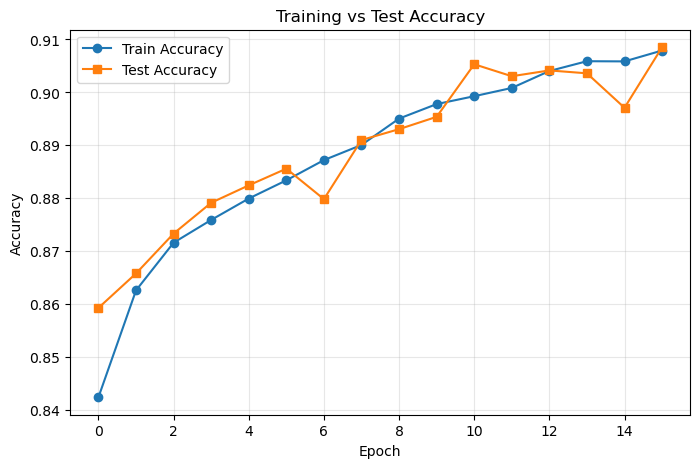

<Figure size 640x480 with 0 Axes>

In [32]:
#training and test accuracy comparison plot
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], marker='o', label="Train Accuracy")
plt.plot(history.history['val_accuracy'], marker='s', label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
plt.savefig("accuracy.png", dpi=300, bbox_inches="tight")

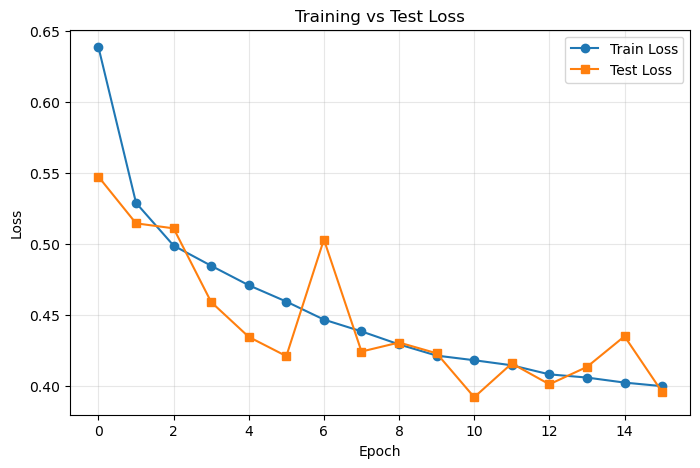

<Figure size 640x480 with 0 Axes>

In [33]:
#training and test loss comaprison plot
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], marker='o', label="Train Loss")
plt.plot(history.history['val_loss'], marker='s', label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
plt.savefig("loss.png", dpi=300, bbox_inches="tight")

In [34]:
# Get final epoch results from training history
final_train_acc = history.history["accuracy"][-1]
final_test_acc = history.history["val_accuracy"][-1]

final_train_loss = history.history["loss"][-1]
final_test_loss = history.history["val_loss"][-1]

# Loss difference (overfitting check)
loss_difference = final_test_loss - final_train_loss
# Print results
print("FINAL MODEL PERFORMANCE")
print(f"Train Accuracy : {final_train_acc:.4f}")
print(f"Test Accuracy  : {final_test_acc:.4f}")
print(f"Train Loss     : {final_train_loss:.4f}")
print(f"Test Loss      : {final_test_loss:.4f}")
print(f"Loss Difference (Test - Train) : {loss_difference:.4f}")

FINAL MODEL PERFORMANCE
Train Accuracy : 0.9079
Test Accuracy  : 0.9085
Train Loss     : 0.3999
Test Loss      : 0.3958
Loss Difference (Test - Train) : -0.0041


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


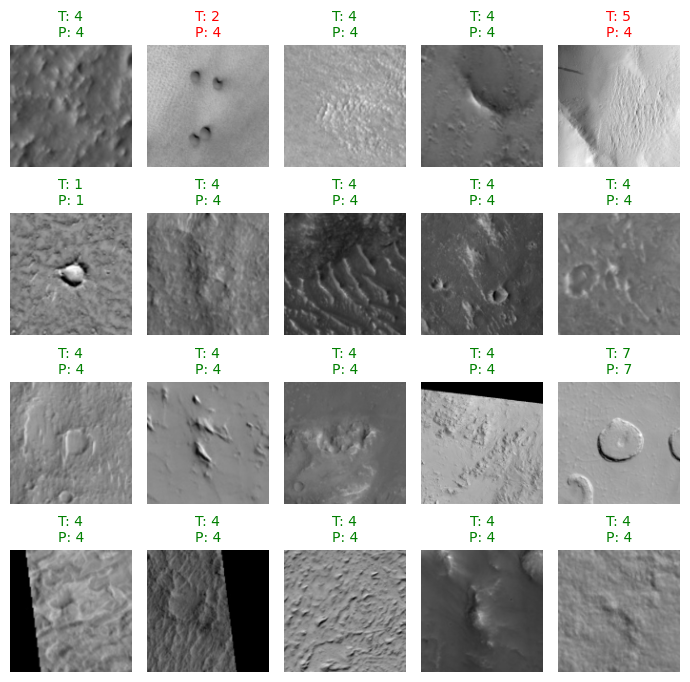

In [39]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Gather all test images and labels into arrays
all_images = []
all_labels = []

for images, labels in test_ds:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Randomly select images
num_images = 20
rows, cols = 4, 5
indices = np.random.choice(len(all_images), num_images, replace=False)

plt.figure(figsize=(7, 7))

for i, idx in enumerate(indices):
    img = all_images[idx]
    true_label = all_labels[idx]

    # Get prediction
    pred = np.argmax(model.predict(img[None, ...]), axis=1)[0]

    ax = plt.subplot(rows, cols, i + 1)
    ax.imshow(img)
    color = 'green' if true_label == pred else 'red'
    ax.set_title(f"T: {true_label}\nP: {pred}", color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

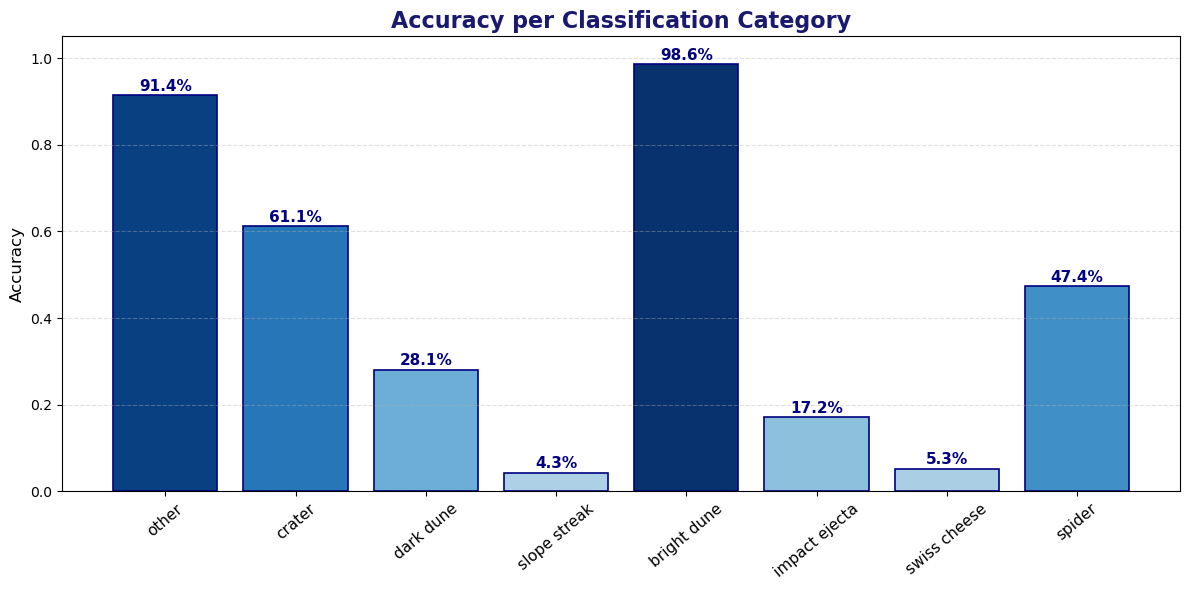

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Predict on the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute accuracy per class
num_classes = 8
class_names = ["other", "crater", "dark dune", "slope streak", 
               "bright dune", "impact ejecta", "swiss cheese", "spider"]

correct_per_class = np.zeros(num_classes)
total_per_class = np.zeros(num_classes)

for i in range(num_classes):
    total_per_class[i] = np.sum(y_true == i)
    correct_per_class[i] = np.sum((y_true == i) & (y_pred == i))

class_accuracy = correct_per_class / total_per_class

# Blue color gradient (light → baby blue → dark blue) 
colors = plt.cm.Blues(0.3 + 0.7 * class_accuracy)

# Plot 
plt.figure(figsize=(12,6))
bars = plt.bar(class_names, class_accuracy, color=colors, edgecolor="navy", linewidth=1.2)

# Add accuracy labels
for bar, acc in zip(bars, class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{acc*100:.1f}%",
             ha='center',
             fontsize=11,
             fontweight='bold',
             color="navy")

plt.title("Accuracy per Classification Category",
          fontsize=16, fontweight='bold', color="midnightblue")

plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.05)

# Soft background grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=40, fontsize=11)
plt.tight_layout()
plt.savefig("class_accuracy_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [37]:

history_df = pd.DataFrame(history.history)
history_df.to_csv("training_history.csv", index=False)

print("Training history saved ")

Training history saved 


In [38]:
# final trained model
model.save("final_model.keras")

# best validation model automatically
checkpoint = keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
# Load training history
history_df = pd.read_csv("training_history.csv")
print("Training history loaded")

# Load only the final trained model
final_model = keras.models.load_model("final_model.keras")
print("Final trained model loaded")

# Results Analysis

For this project, the **Convolutional Neural Network** achieved **90.79% training accuracy** and **90.85% test accuracy**, with a small difference in loss of **-0.0041**.

### Per-Class Performance
Per-class accuracy shows the following results:

- **Other:** 91.4%
- **Crater:** 61.1%
- **Dark Dune:** 28.1%
- **Slope Streak:** 4.3%
- **Bright Dune:** 98.6%
- **Impact Ejecta:** 17.2%
- **Swiss Cheese:** 5.3%
- **Spider:** 47.4%

Frequent classes like *Bright Dune* and *Other* had high accuracy, but less common or less visually distinct classes like *Slope Streak*, *Swiss Cheese*, and *Dark Dune* had lower accuracy.
This is an example of **dataset imbalance**.

### Test Predictions
For the 20 randomly chosen images of the test data, the CNN was successful in classifying the images *correctly for 18 out of the 20 images*, resulting in only *2 incorrect classifications*. This proves that the CNN generalizes the data for most of the classes and can differentiate between the different Martian surface features.

### Observations
- The classes that have small textures were not easy to classify correctly.
- The pre-processing and the usage of the stratified sampling helped the model generalize well.
- The experiments that were conducted using class weighting, sophisticated augmentation, and the usage of extra layers did not show improvements in the accuracy of the model because of overfitting.
- The CNN model is good for the automatic classification of the Martian features on the surface of the planet.